# Inside the Riksdag: A data-driven look at Swedish parliamentary motions

---

## The brief

> **Publication:** Dagens Data (fictional Swedish data journalism outlet)
>
> **Your role:** Data journalist
>
> **Context:** Sweden's parliamentary election is approaching. Your editor wants a data-driven feature exploring what politicians actually spend their time proposing. You have access to a dataset of over 16,000 parliamentary motions from 2020-2024, including AI-generated summaries and ideological classifications.
>
> **Your task:** Explore this dataset, create compelling visualizations, and uncover insights that would interest readers. Think like a journalist: What stories does this data tell? What surprises you? What patterns emerge?

---

## Understanding parliamentary motions

A **motion** is a formal proposal submitted by members of parliament. Anyone in the Riksdag can submit a motion suggesting new laws, policy changes, or government actions. Most motions don't become law, but they reveal what politicians prioritize and how parties differ.

### What's in this dataset?

Each row represents one motion. Key columns include:

- **party** - The political party of the main author
- **main_author** - The politician who submitted the motion
- **handed_in** - Date submitted
- **key_political_area** - Topic category (Law, Health, Economy, etc.)
- **economic_direction** - Classified as left, neutral, or right
- **democratic_direction** - Classified as authoritarian, neutral, or libertarian
- **summary** - AI-generated English summary of the motion

<details>
<summary><strong>Click here for full column reference</strong></summary>

| Column | Description |
|--------|-------------|
| `id` | Motion identifier |
| `title` | Swedish title of the motion |
| `main_author` | Politician who submitted the motion |
| `party` | Political party affiliation |
| `type` | Document type (mot = motion) |
| `motion_id` | Full motion identifier |
| `handed_in` | Date the motion was submitted |
| `summary` | AI-generated English summary |
| `economic_direction` | Ideological classification: left, neutral, or right |
| `democratic_direction` | Ideological classification: authoritarian, neutral, or libertarian |
| `key_political_area` | Topic category |
</details>

### Swedish political parties (for reference)

| Abbr | Party | English | Traditional position |
|------|-------|---------|---------------------|
| S | Socialdemokraterna | Social Democrats | Center-left |
| M | Moderaterna | Moderates | Center-right |
| SD | Sverigedemokraterna | Sweden Democrats | Right-wing populist |
| C | Centerpartiet | Centre Party | Liberal/agrarian |
| V | Vänsterpartiet | Left Party | Left-wing |
| KD | Kristdemokraterna | Christian Democrats | Center-right |
| MP | Miljöpartiet | Green Party | Green |
| L | Liberalerna | Liberals | Liberal |

---

## A note on data quality

Like most real-world datasets, this one has some quirks. A good data journalist always checks their data before publishing!

**Things to be aware of:**

- **Missing values:** About 7% of rows are missing `party` and `main_author` values
- **Party naming:** Most entries use abbreviations (M, S, SD...), but some use full names ("Moderaterna", "Centerpartiet")
- **Multi-party motions:** A few motions were submitted by multiple parties together (e.g., "M, KD")
- **Ideology columns:** A small number of rows (~143) have values that seem misclassified

**Tip:** Before diving into analysis, use `value_counts()` to understand what values you're actually working with. For clean party comparisons, you may want to filter to the main 8 parties:

```python
main_parties = ['M', 'S', 'SD', 'C', 'KD', 'MP', 'V', 'L']
df_clean = df[df['party'].isin(main_parties)]
```

---

# The analysis

*Add cells below to explore the data and create visualizations. Structure your notebook with clear sections and markdown headers. Include written insights interpreting what you find.*

*Remember: You're building a story. Each visualization should have context and a takeaway.*

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("political_motions.csv")

### Reviewing and cleaning the data

In [14]:
# Looking at the data
df.head()

,id,title,main_author,party,type,motion_id,handed_in,summary,economic_direction,democratic_direction,key_political_area,submitted_by,motion_category,assigned_to,motion_deadline
0,2021/22:1792,Stärkande av Sveriges arbete för ett fritt Väs...,Elin Gustafsson,S,mot,Motion 2021/22:1792 av Elin Gustafsson m.fl. (S),2021-09-30,The motion proposes that the Swedish Parliamen...,left,neutral,Human Rights and Equality,NaN,NaN,NaN,NaN
1,2021/22:1791,FN-erkännande av folkmordet 2014 på kristna fo...,Robert Halef,KD,mot,Motion 2021/22:1791 av Robert Halef (KD),2021-09-30,The motion proposes that the Swedish Parliamen...,neutral,neutral,Human Rights and Equality,NaN,NaN,NaN,NaN
2,2021/22:1790,Syrianska kyrkor och kloster i Turkiet,Robert Halef,KD,mot,Motion 2021/22:1790 av Robert Halef (KD),2021-09-30,"The motion proposes that Sweden, through Unesc...",neutral,neutral,Culture and Heritage,NaN,NaN,NaN,NaN
3,2021/22:1789,Stöd till Libanon,Robert Halef,KD,mot,Motion 2021/22:1789 av Robert Halef (KD),2021-09-30,The suggestion calls for Sweden to advocate fo...,left,neutral,Foreign Affairs and International Relations,NaN,NaN,NaN,NaN
4,2021/22:1788,Den väpnade konflikten om Nagorno-Karabach mel...,Robert Halef,KD,mot,Motion 2021/22:1788 av Robert Halef (KD),2021-09-30,This motion calls for the Swedish Parliament t...,neutral,neutral,Foreign Affairs and International Relations,NaN,NaN,NaN,NaN


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16420 entries, 0 to 16419
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    16419 non-null  object
 1   title                 16420 non-null  object
 2   main_author           15227 non-null  object
 3   party                 15227 non-null  object
 4   type                  16420 non-null  object
 5   motion_id             16420 non-null  object
 6   handed_in             16312 non-null  object
 7   summary               16277 non-null  object
 8   economic_direction    16277 non-null  object
 9   democratic_direction  16277 non-null  object
 10  key_political_area    16277 non-null  object
 11  submitted_by          22 non-null     object
 12  motion_category       3185 non-null   object
 13  assigned_to           3201 non-null   object
 14  motion_deadline       22 non-null     object
dtypes: object(15)
memory usage: 1.9+ MB


In [16]:
df.describe()

,id,title,main_author,party,type,motion_id,handed_in,summary,economic_direction,democratic_direction,key_political_area,submitted_by,motion_category,assigned_to,motion_deadline
count,16419,16420,15227,15227,16420,16420,16312,16277,16277,16277,16277,22,3185,3201,22
unique,15707,11282,595,22,3,16312,629,16277,5,4,20,8,2,15,7
top,2022/23:1,Motionen utgår,Markus Wiechel,M,mot,Proposition 2023/24:1,2020-10-06,The motion proposes that the Swedish Parliamen...,left,neutral,Law and Justice,Justitiedepartementet,Independent motion,Transport Committee,2024-10-02
freq,26,111,580,4021,12387,29,942,1,6495,8450,2072,8,3159,398,8


In [17]:
# Removing the columns with to many null values to work with (submitted_by, motion_category, assigned_to, motion_deadline)

df =df.dropna(axis=1,thresh=15000)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16420 entries, 0 to 16419
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    16419 non-null  object
 1   title                 16420 non-null  object
 2   main_author           15227 non-null  object
 3   party                 15227 non-null  object
 4   type                  16420 non-null  object
 5   motion_id             16420 non-null  object
 6   handed_in             16312 non-null  object
 7   summary               16277 non-null  object
 8   economic_direction    16277 non-null  object
 9   democratic_direction  16277 non-null  object
 10  key_political_area    16277 non-null  object
dtypes: object(11)
memory usage: 1.4+ MB


In [18]:
# Checking how the parties are labeled, and noticed same party can be labeled differently. 
df['party'].value_counts()

party
M                     4021
S                     3281
SD                    3154
C                     1694
KD                    1134
MP                     698
V                      627
L                      471
-                       58
M, KD                   26
Centerpartiet           25
Kristdemokraterna       21
Miljöpartiet             4
M, C, KD                 3
Moderaterna              2
MP, S                    2
Socialdemokraterna       1
M, SD, KD, L             1
KD, M                    1
Unknown                  1
M, L                     1
C, S, L                  1
Name: count, dtype: int64

In [19]:
# Changing the full party names to abbreviations, to match the format of the other entries by the same party. 

party_dict = {
    'Moderaterna': 'M', 
    'Socialdemokraterna': 'S',
    'Centerpartiet': 'C',
    'Kristdemokraterna': 'KD',
    'Miljöpartiet': 'MP',
    'Sverigedemokraterna': 'SD', 
    'Liberalerna': 'L', 
    'Vänsterpartiet': 'V'
}

df['party'] = df['party'].replace(party_dict)
df['party'].value_counts()

party
M               4023
S               3282
SD              3154
C               1719
KD              1155
MP               702
V                627
L                471
-                 58
M, KD             26
M, C, KD           3
MP, S              2
M, SD, KD, L       1
KD, M              1
Unknown            1
M, L               1
C, S, L            1
Name: count, dtype: int64

In [20]:
# Filtering the DataFrame to only include the top 8 partys. 
partys = ['M', 'S', 'C', 'KD', 'MP', 'SD', 'L', 'V']

df = df[df['party'].isin(partys)]

# The Party Landscape

Text(0, 0.5, 'Motions')

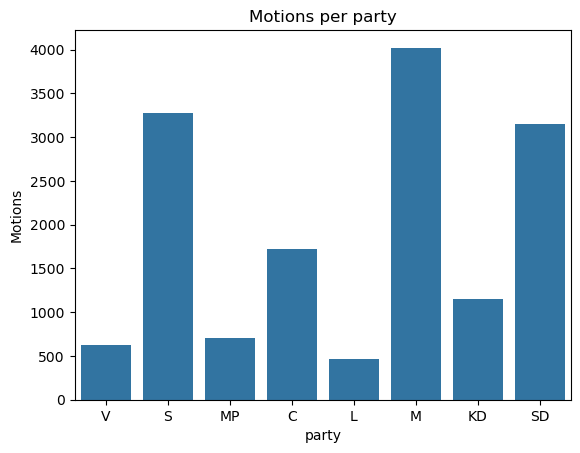

In [24]:
# Quickly visualising motions per party
sns.countplot(data=df, x='party',order=['V', 'S', 'MP', 'C', 'L', 'M', 'KD', 'SD'])
plt.title('Motions per party')
plt.ylabel('Motions')

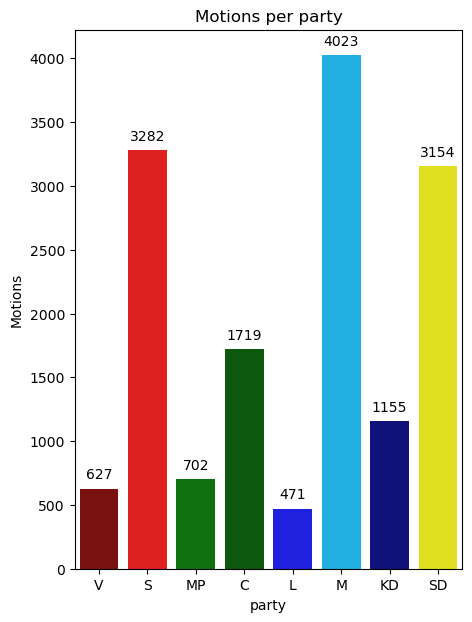

In [25]:
# Making it prettier
# Defining fitting custom color palette for parties
party_colors = {
    'V': 'darkred',
    'S': 'red',
    'MP': 'green',
    'C': 'darkgreen',
    'L': 'blue',
    'M': 'deepskyblue',
    'KD': 'darkblue',
    'SD': 'yellow'
}

# Create the countplot with custom colors
plt.figure(figsize=(5,7))
ax = sns.countplot(data=df, x='party', order=['V', 'S', 'MP', 'C', 'L', 'M', 'KD', 'SD'], 
                  palette=party_colors, hue='party', legend=False)
plt.title('Motions per party')
plt.ylabel('Motions')

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom',
                xytext = (0, 5), textcoords = 'offset points')

Take aways
- M submitted the most motions during the period. Despite only having second most representatives in Riksdagen between 2018-2022, and third most after S and SD after the election 2022.
- Surprisingly S submitted significantly less. During the time period they had 30 more representatives than M in Riksdagen between 2018-2022, and 39 more after the election in 2022. 

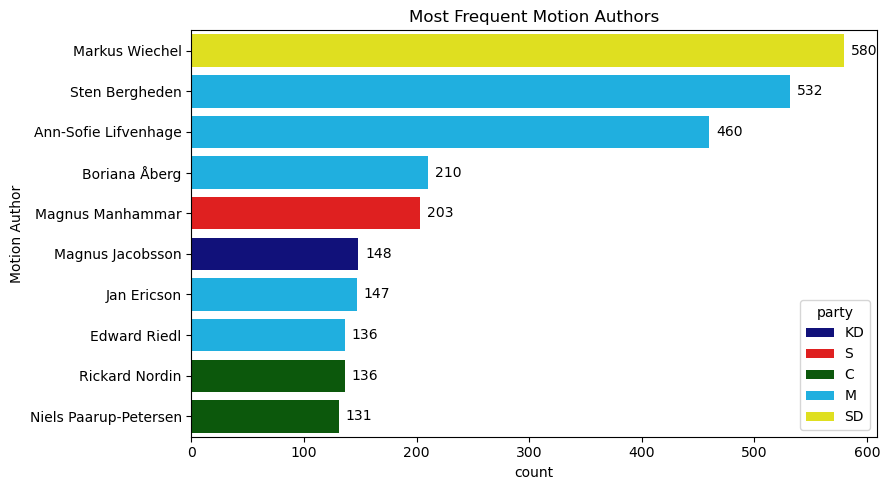

In [36]:
# Plotting motions per submitter and highlighting what party they belong to. 
party_colors = {
    'V': 'darkred',
    'S': 'red',
    'MP': 'green',
    'C': 'darkgreen',
    'L': 'blue',
    'M': 'deepskyblue',
    'KD': 'darkblue',
    'SD': 'yellow'
}

top_authors = df['main_author'].value_counts().nlargest(10).index
df_top_authors = df[df['main_author'].isin(top_authors)] 
plt.figure(figsize=(9,5)) 
ax = sns.countplot(data=df_top_authors, y='main_author', order=top_authors, hue='party', palette=party_colors)
plt.title('Most Frequent Motion Authors')
plt.ylabel('Motion Author')
# Making it visually prettier below 
for p in ax.patches:
    width = p.get_width()
    if width <= 0:
        continue               
    ax.annotate(f'{int(width)}',
                xy=(width, p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')

# Adjusting layout to prevent label cutoff
plt.tight_layout()

Take aways
- The top motion submitter is Markus Wiechel from SD.
- M have five of the top ten motion submitters.
- S only has one motion submitter in the top 10. Points towards them having a lot of people submitting motions, spreading the count over multiple people. 

# Political Priorities 

In [29]:
# Checking what key political areas we have in the data
df['key_political_area'].value_counts(ascending=False).index

Index(['Law and Justice', 'Economy and Finance', 'Health and Healthcare',
       'Infrastructure and Transportation',
       'Environment and Natural Resources', 'Education and Research',
       'Social Welfare and Services', 'Government and Public Administration',
       'Housing and Urban Development', 'Human Rights and Equality',
       'Foreign Affairs and International Relations',
       'Agriculture and Fisheries', 'Labor and Employment',
       'Defense and Security', 'Culture and Heritage',
       'Immigration and Integration', 'Energy', 'Technology and Innovation',
       'Sports', 'Media and Communications'],
      dtype='object', name='key_political_area')

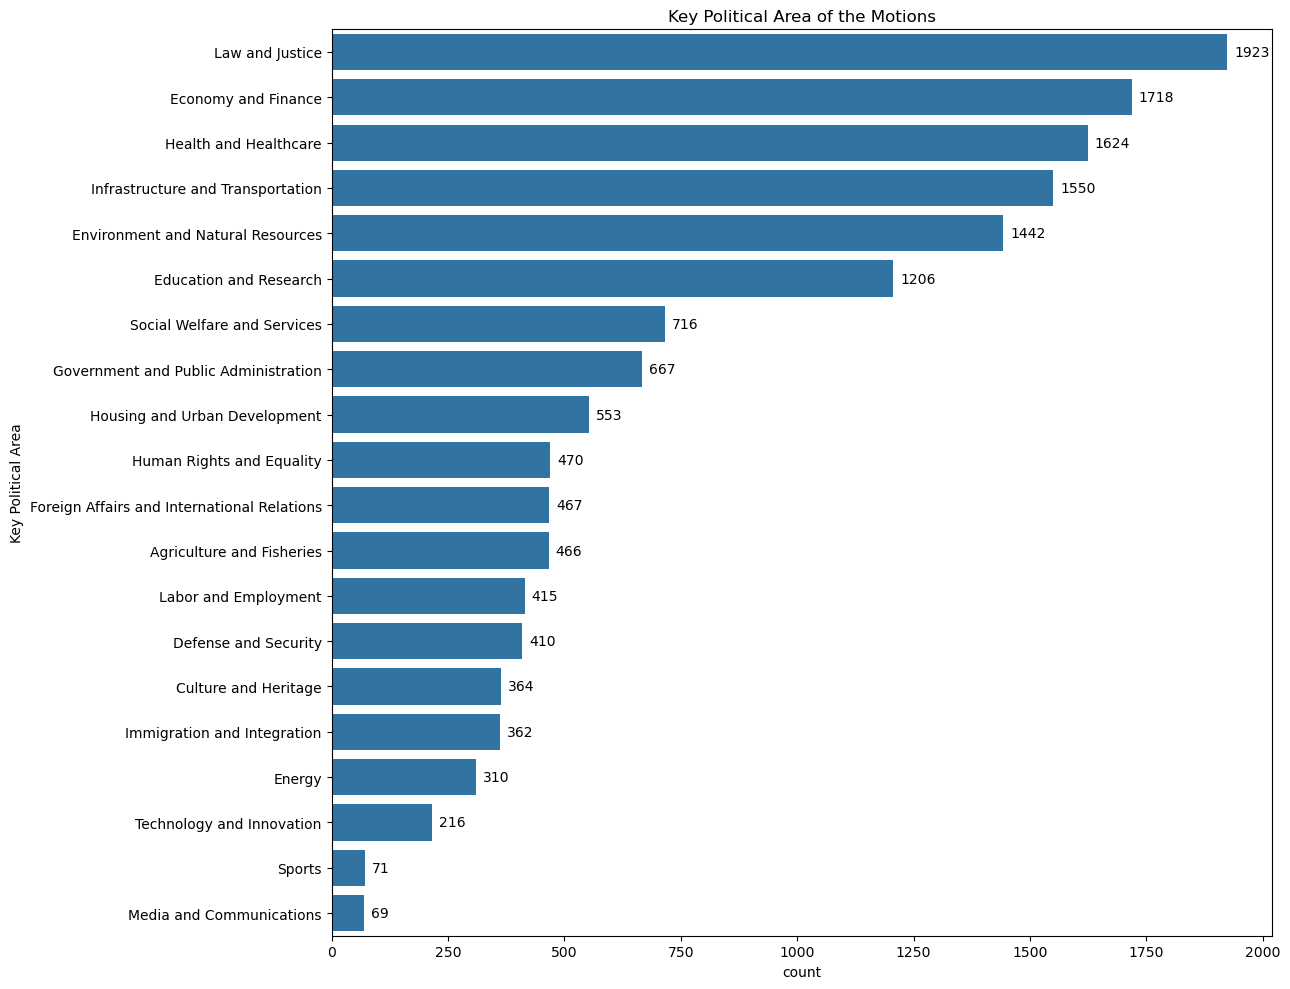

In [37]:
# Plotting motions per key political area
party_colors = {
    'V': 'darkred',
    'S': 'red',
    'MP': 'green',
    'C': 'darkgreen',
    'L': 'blue',
    'M': 'deepskyblue',
    'KD': 'darkblue',
    'SD': 'yellow'
}

ordered_areas = df['key_political_area'].value_counts(ascending=False).index

plt.figure(figsize=(13,10)) 
ax = sns.countplot(data=df, y='key_political_area', order=ordered_areas)
plt.title('Key Political Area of the Motions')
plt.ylabel('Key Political Area')

for p in ax.patches:
    width = p.get_width()
    if width <= 0:
        continue               
    ax.annotate(f'{int(width)}',
                xy=(width, p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()

Take aways
- Law and Justice dominate the first place. That is the area with most motions submitted.
- Economy and Finance, Health and Healthcare, Infrastructure and Transportation, Environment and Natural Resources, Education and Research. They are the rest of the top 6 areas. After that there is quite a big drop off to number 7 on the list.
- 'Sports' and 'Media and Communications' have by far the fewest submitted motions.  

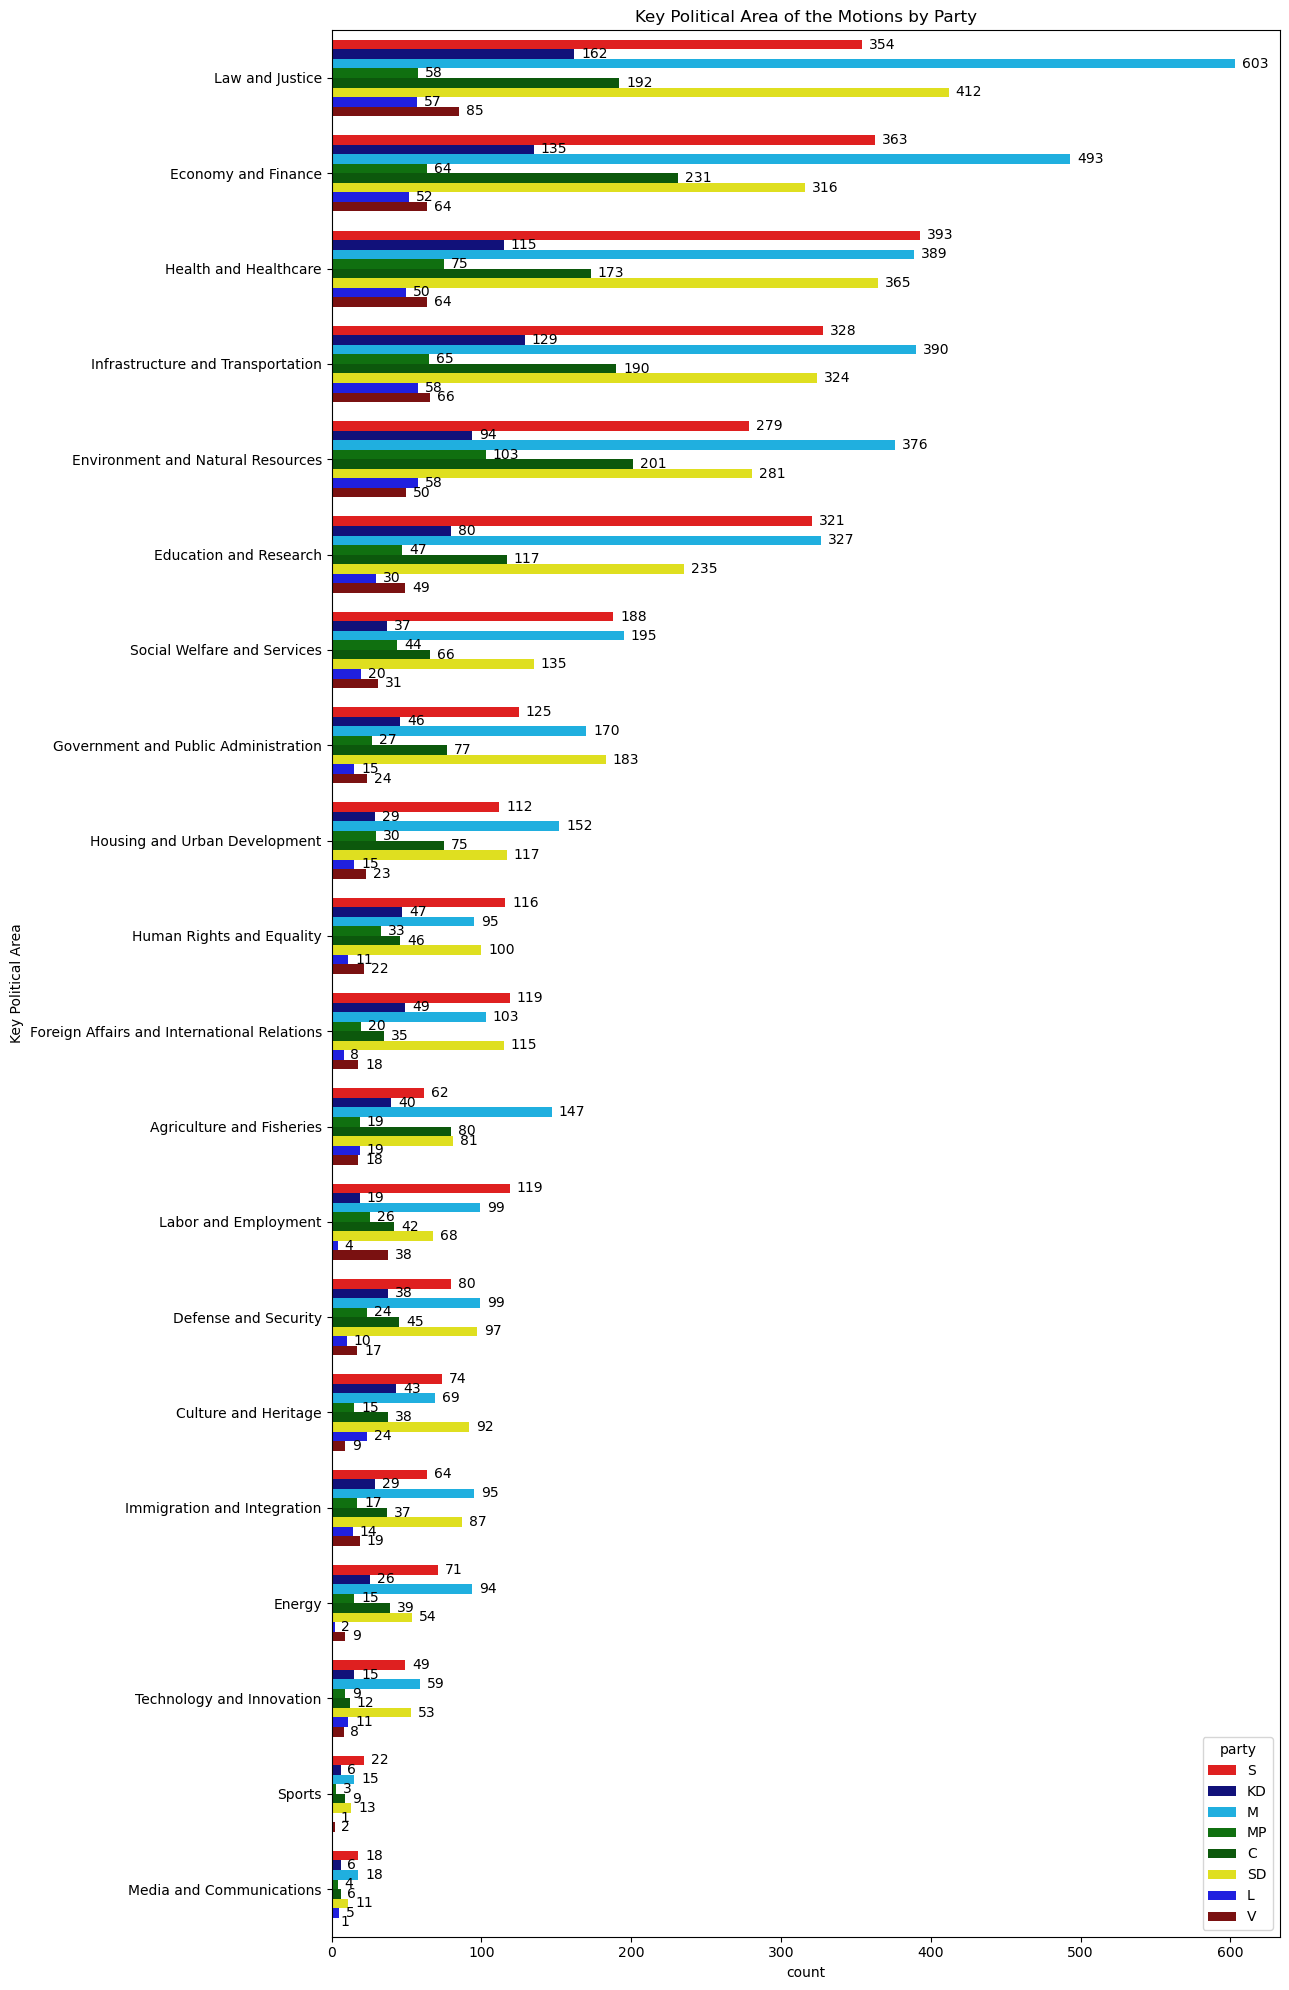

In [38]:
# Plotting key plotical areas per party, to better understand what they want to focus on and prioritize with their politics. 
party_colors = {
    'V': 'darkred',
    'S': 'red',
    'MP': 'green',
    'C': 'darkgreen',
    'L': 'blue',
    'M': 'deepskyblue',
    'KD': 'darkblue',
    'SD': 'yellow'
}

ordered_areas = df['key_political_area'].value_counts(ascending=False).index

plt.figure(figsize=(13,20)) 
ax = sns.countplot(data=df, y='key_political_area', order=ordered_areas, hue='party', palette=party_colors)
plt.title('Key Political Area of the Motions by Party')
plt.ylabel('Key Political Area')

for p in ax.patches:
    width = p.get_width()
    if width <= 0:
        continue               
    ax.annotate(f'{int(width)}',
                xy=(width, p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()

Take aways
- M has submitted by far the most motions in Law and Justice. They are also very invested in Economy and Fincance, compared to other partys.
- M are also by far the most frequent submitter of motions in the category 'Agriculture and Fishery', which is somewhat surprising. 
- S are at the top or close to the top in 'Health and Healthcare', 'Education and Research', 'Foreign affairs and international relations' and 'Labor and employment'
- Unsurprisingly SD are at or close to the top in 'Immegration and Integration', 'Culture and Heritage' and 'Defense and Security'. They also top 'Government and Public Administration'

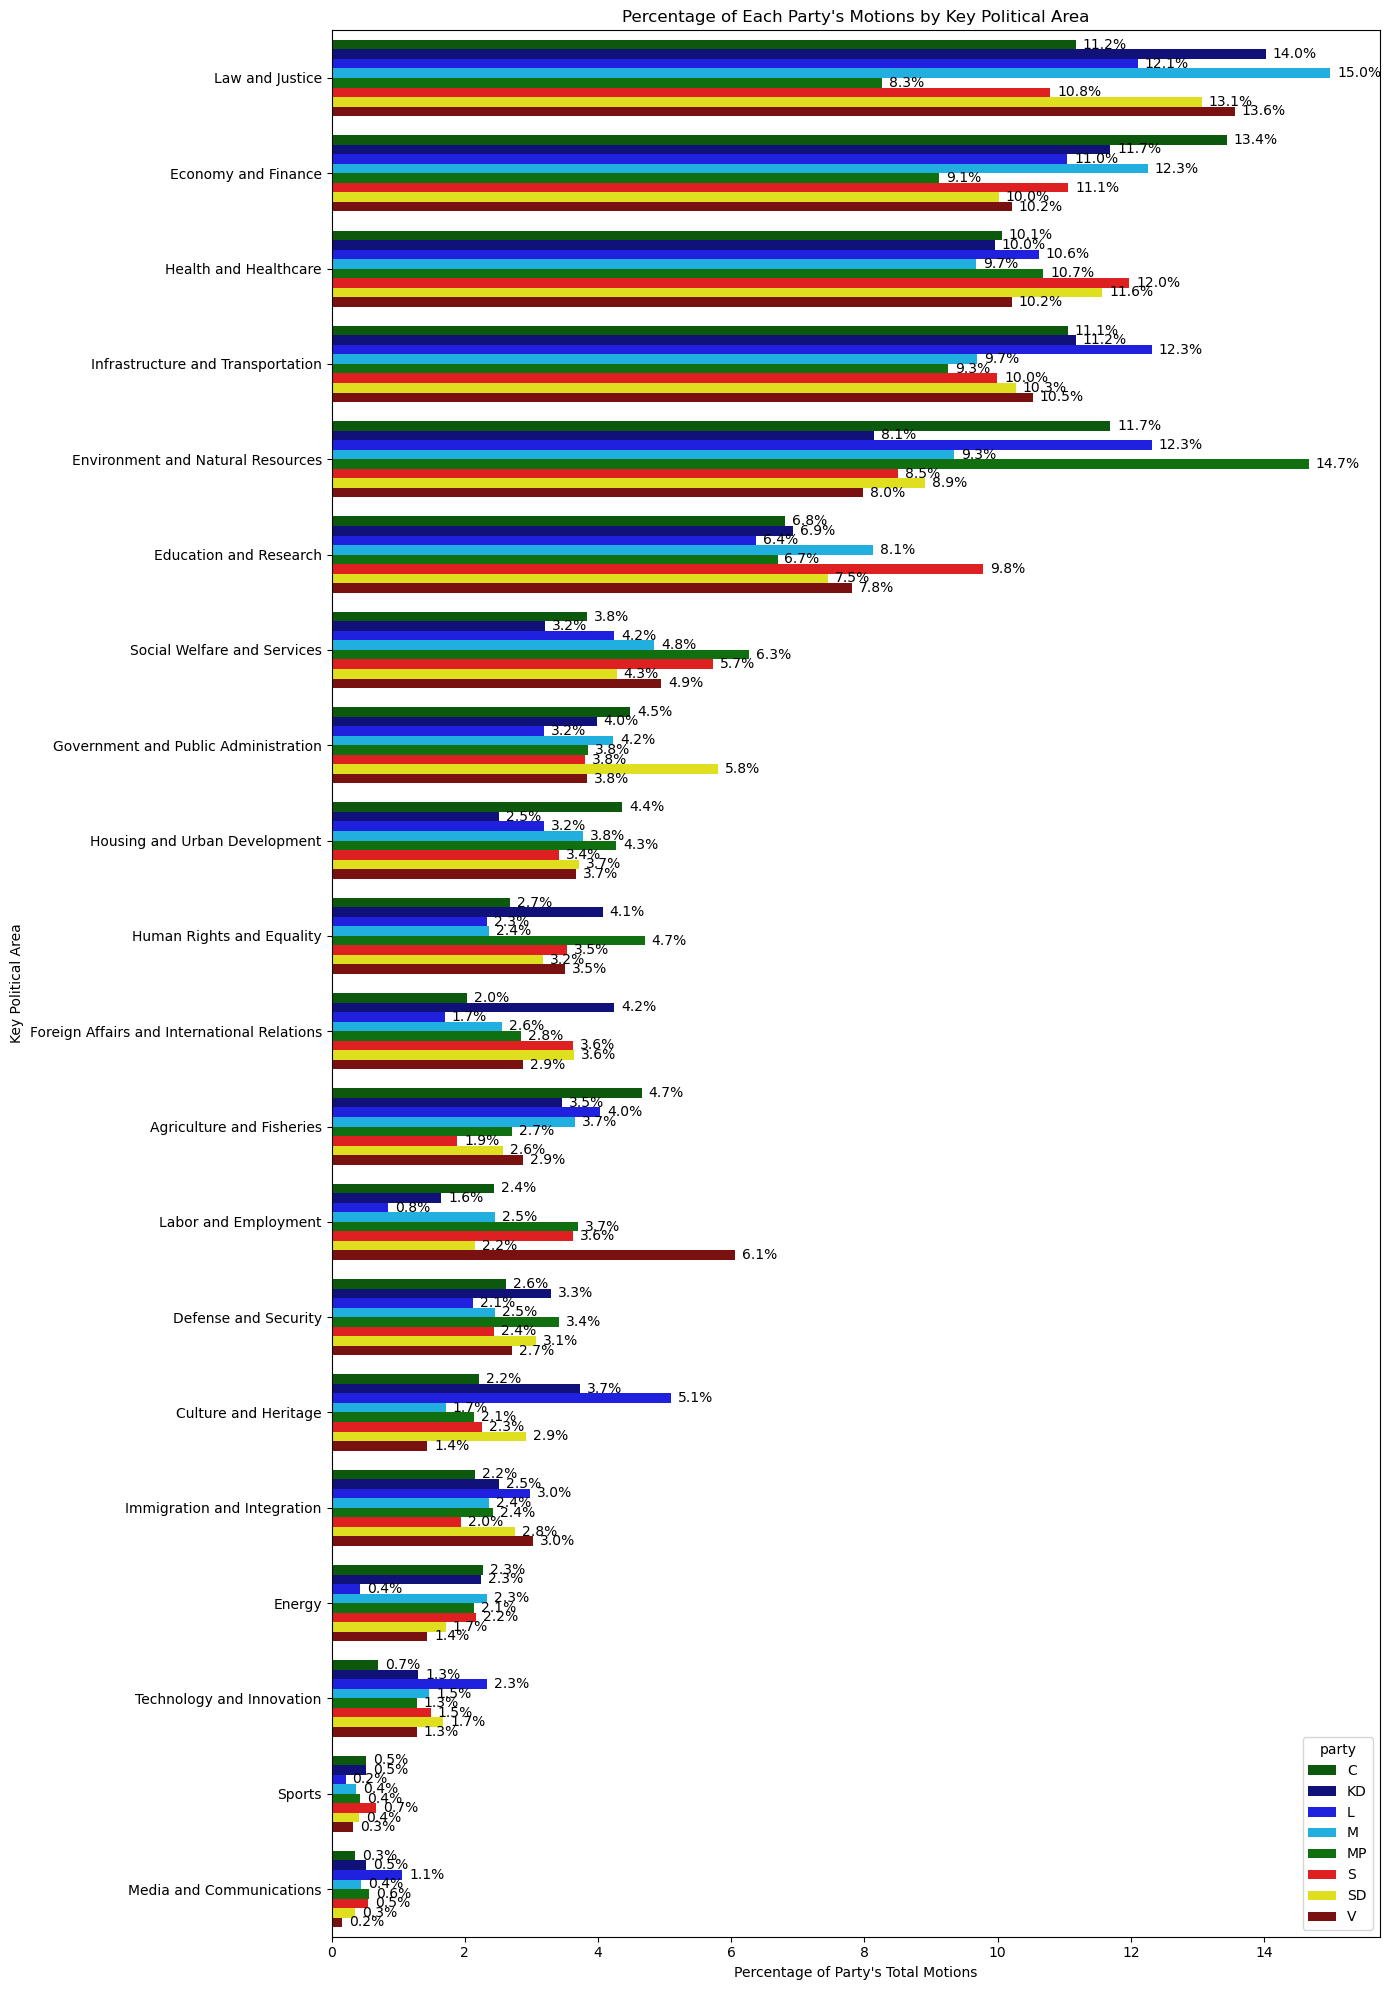

In [39]:
# Plotting how many percent of their total motions that the party have submitted in a key political area. To even further underastand what they prioritize with their politics. 

party_colors = {
    'V': 'darkred',
    'S': 'red',
    'MP': 'green',
    'C': 'darkgreen',
    'L': 'blue',
    'M': 'deepskyblue',
    'KD': 'darkblue',
    'SD': 'yellow'
}

# Geting top political areas
top_ordered_areas = df['key_political_area'].value_counts(ascending=False).index

# Creating a new dataframe with percentages

# First, get the total count of motions for each party
party_totals = df['party'].value_counts()

# Creating a cross-tabulation of party and key_political_area
cross_tab = pd.crosstab(df['party'], df['key_political_area'])

# Calculating percentages
percentage_df = cross_tab.div(party_totals, axis=0) * 100

# Converting to long format for seaborn
percentage_df_long = percentage_df.reset_index().melt(
    id_vars=['party'], 
    value_vars=top_ordered_areas,
    var_name='key_political_area', 
    value_name='percentage'
)

# Creating the plot
plt.figure(figsize=(14, 20))
ax = sns.barplot(
    data=percentage_df_long[percentage_df_long['key_political_area'].isin(top_ordered_areas)],
    y='key_political_area',
    x='percentage',
    hue='party',
    palette=party_colors,
    order=top_ordered_areas
)

plt.title('Percentage of Each Party\'s Motions by Key Political Area')
plt.xlabel('Percentage of Party\'s Total Motions')
plt.ylabel('Key Political Area')

# Adding percentage annotations
for p in ax.patches:
    width = p.get_width()
    if width <= 0:
        continue  # skip zero-width segments
    ax.annotate(f'{width:.1f}%',
                xy=(width, p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()

Take aways 

- M spent 15% of the motions on Law and Justice. The most by any party in any category.
- Some interesting outliers are:
  * V - "Labour and Employment" - 6.1% of their total motions.
  * L - "Labour and Employment" - Only 0.8% of their total motions.
  * L - "Energy" - Only 0.4% compared to the second lowest in that category on 1.4%.
  * There is a clear difference in how important the environmental questions are to different parties.

# Changes over time

In [41]:
# Looking at the value counts
df['handed_in'].value_counts()

handed_in
2020-10-06    935
2024-10-03    859
2023-10-05    849
2022-11-23    788
2020-10-05    777
             ... 
2021-02-08      1
2020-02-07      1
2021-02-03      1
2020-02-04      1
2023-05-10      1
Name: count, Length: 411, dtype: int64

In [42]:
# Checking the data type
df['handed_in'].dtype

dtype('O')

In [43]:
# Changing to datetype 
df['handed_in'] = pd.to_datetime(df['handed_in'])

In [44]:
# Adding a month and year column for easier comparisons 
df['month_start_date'] = df['handed_in'].dt.to_period('M').dt.to_timestamp()
df['year'] = df['handed_in'].dt.year

Text(0, 0.5, 'Motions')

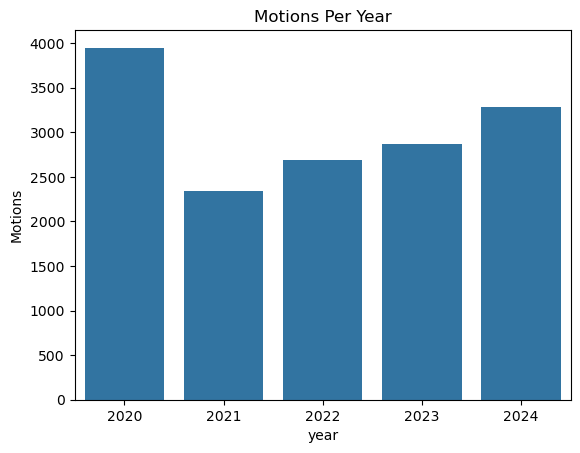

In [45]:
# Plotting motions filed per year

sns.countplot(data=df, x='year')
plt.title('Motions Per Year')
plt.ylabel('Motions')

Take away
- Most motions were filed in 2020
- Noticeable decrease in 2021
- Steady year over year increase since

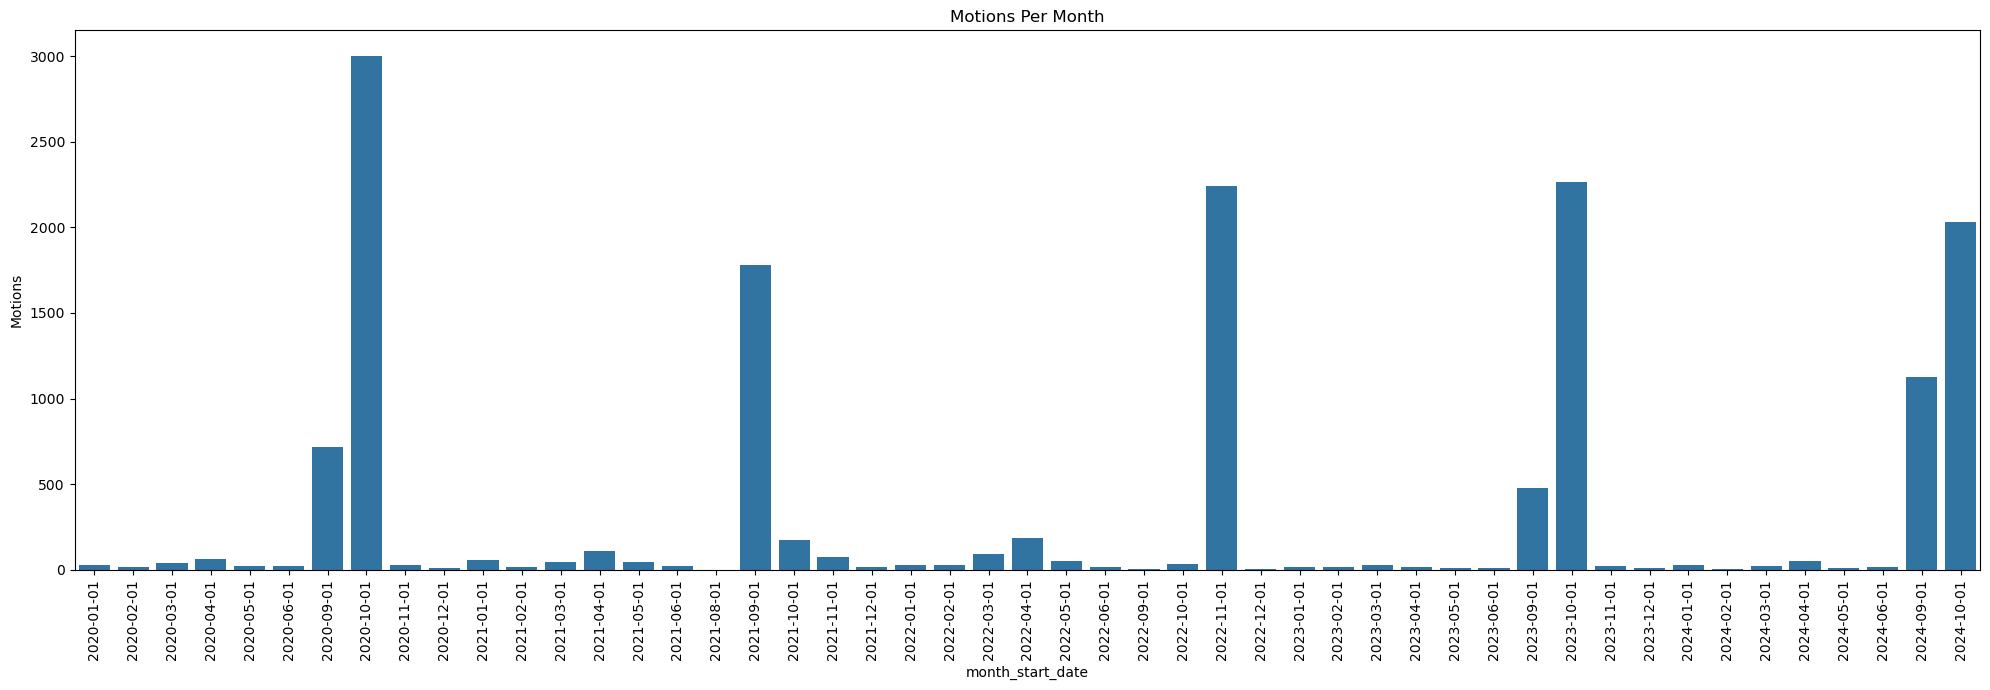

In [46]:
# Plotting motions per month
df_sorted = df.sort_values(by='month_start_date')
plt.figure(figsize=(20,7))
sns.countplot(data=df_sorted, x='month_start_date') 

plt.title('Motions Per Month')
plt.ylabel('Motions')
plt.xticks(rotation=90)  
plt.tight_layout()      
plt.show()

Take away
- The absolute majority of motions are supposed to be filed annualy after the opening of Riskdagen (usually in late September) and the 14 days following. This is clearly visible in the data.

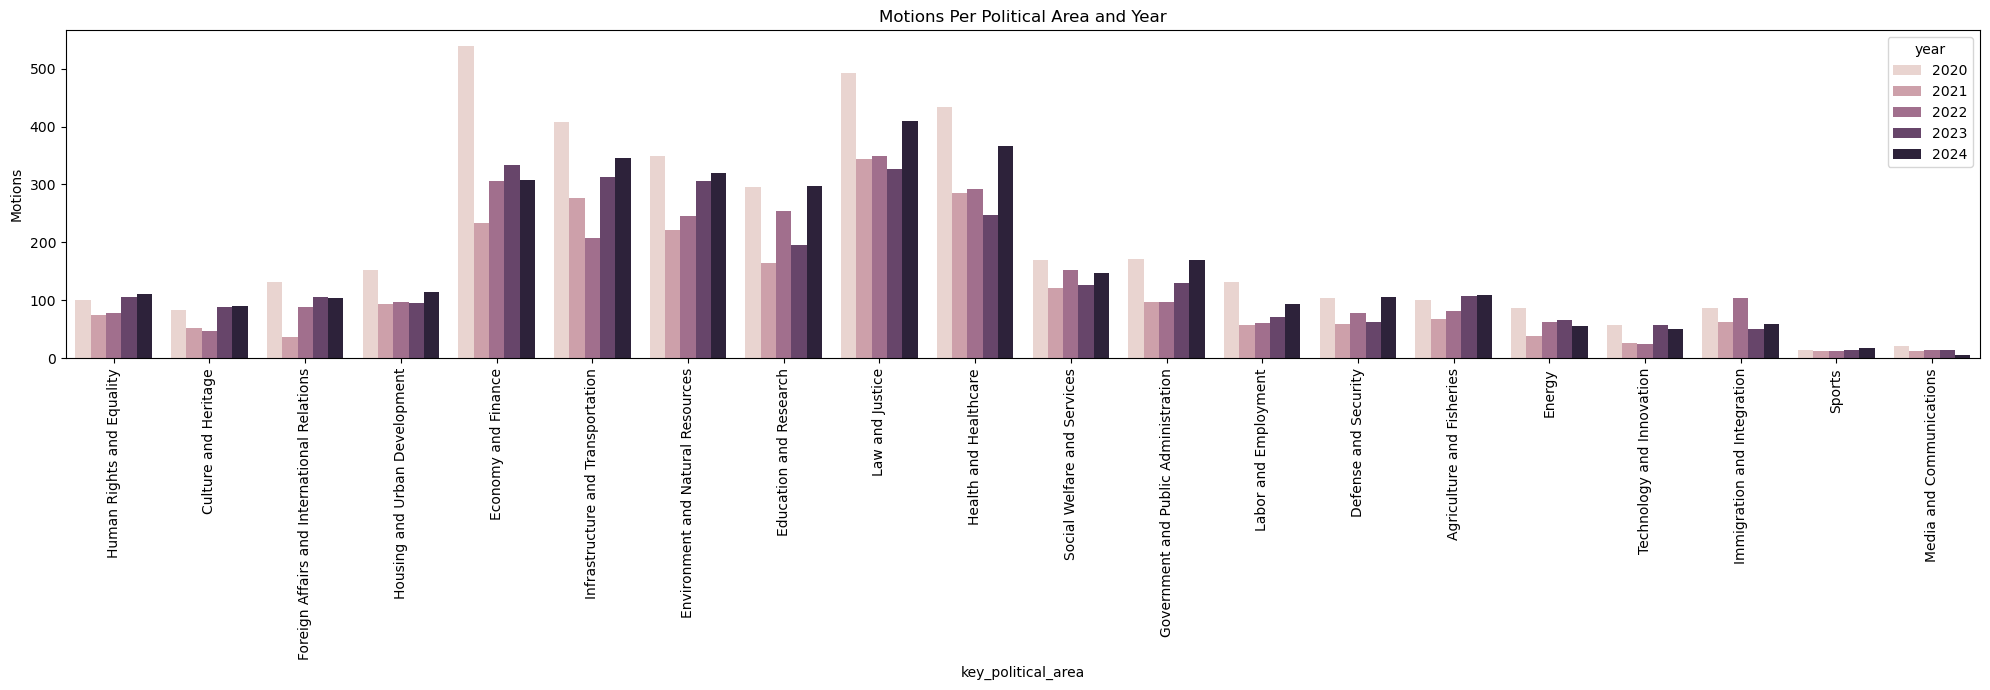

In [48]:
# Visualising motions per political area and year. To see if some questions seemed more pressing some years compared to others. 
plt.figure(figsize=(20,7)) 
sns.countplot(data=df, x='key_political_area', hue='year')

plt.title('Motions Per Political Area and Year')
plt.ylabel('Motions')
plt.xticks(rotation=90)   
plt.tight_layout()        
plt.show()

Take away
- In 2020 'Economy and Finance', 'Law and Justice', 'Health and Healthcare', 'Infrastructure and Transportation', 'Education and Research' and 'Environment and Natural Recources' dominated the politcal landscape.
  * One can assume the the Covid-19 pandemic had a big impact on this. As well as the environmental issues that was a big talking point at the time.
- 'Health and Healthcare', 'Law and Justice', 'Education and Research' and 'Infrastructure and Transportation' have all had big increase in the last year or two after going down after 2020.
  * The increas in gang related violence, the adaptaion of AI into our school system are example of topics that likely paticipated in this.
- An interesting finding is the increase in motions filed sorrounding 'Foregin affairs and international relations' as well as 'Defense and security' from 2021 and onwards.
  * The geo politcal landscape is clearly impacting this. With Russias invasion of Ukraine, the Nato-question, the American re-election, the war in Gaza and Palestine, etc etc, it looks as if it clearly effects the Swedish Riksdag. 

# Summary findings 

 

Party size impacting motions submitted
- M submitted the most motions during the period. Despite only having second most representatives in Riksdagen between 2018-2022, and third most after S and SD after the election 2022.
- Surprisingly S submitted significantly less. During the time period they had 30 more representatives than M in Riksdagen between 2018-2022, and 39 more after the election in 2022.
- However, overall the biggest parties, M, SD and S together make out a clear majority of the amount of motions submitted. Suggesting that larger parties more actively use motions as a political tool.
- M have five of the top ten motion submitters and S only has one motion submitter in the top 10, yet are top three in total motions. It is obvious that these parties have a lot of resources.

Political Priorities
- M has submitted by far the most motions in Law and Justice. They are also very invested in Economy and Fincance, compared to other partys.
- M are also by far the most frequent submitter of motions in the category 'Agriculture and Fishery', which is somewhat surprising.
- S are at the top or close to the top in 'Health and Healthcare', 'Education and Research', 'Foreign affairs and international relations' and 'Labor and employment'
- Unsurprisingly SD are at or close to the top in 'Immegration and Integration', 'Culture and Heritage' and 'Defense and Security'. They also top 'Government and Public Administration'
- M spent 15% of the motions on Law and Justice. The most by any party in any category.
- Some interesting outliers are:
  * V - "Labour and Employment" - 6.1% of their total motions.
  * L - "Labour and Employment" - Only 0.8% of their total motions.
  * L - "Energy" - Only 0.4% compared to the second lowest in that category on 1.4%.
  * There is a clear difference in how important the environmental questions are to different parties.

Priorities over time 

- In 2020 'Economy and Finance', 'Law and Justice', 'Health and Healthcare', 'Infrastructure and Transportation', 'Education and Research' and 'Environment and Natural Recources' dominated the politcal landscape.
  * One can assume the the Covid-19 pandemic had a big impact on this. As well as the environmental issues that was a big talking point at the time.
- 'Health and Healthcare', 'Law and Justice', 'Education and Research' and 'Infrastructure and Transportation' have all had big increase in the last year or two after going down after 2020.
  * The increas in gang related violence, the adaptaion of AI into our school system are example of topics that likely paticipated in this.
- An interesting finding is the increase in motions filed sorrounding 'Foregin affairs and international relations' as well as 'Defense and security' from 2021 and onwards.
  * The geo politcal landscape is clearly impacting this. With Russias invasion of Ukraine, the Nato-question, the American re-election, the war in Gaza and Palestine, etc etc, it looks as if it clearly effects the Swedish Riksdag.
